### Indice Municipal
Tratamiento, normalización y construcción del índice compuesto.
Autor: Diego Carcamo| Proyecto de Sostenibilidad 
 

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
pd.set_option('display.max_columns', None)
 
# Reemplaza con la ruta real de tu archivo
DATA_PATH = "../data/index/processed/dataset_indicadores_municipales.csv"
 
df = pd.read_csv(DATA_PATH)
df.head()

,Unnamed: 0,departamento,municipio,solar_power_mean,solar_power_min,solar_power_max,codigo_departamental,codigo_municipal,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,capacidad_de_respuesta,desarrollo_y_pobreza,infraestructura,ice,iae
0,0,Islas De La Bahia,Guanaja,1988.934501,1898.935059,2023.484985,HN11,HN1102,0.0,0.0,8.8,0.0,0.0,6.6,3.3,4.5,4.7,NaN,NaN
1,1,Islas De La Bahia,Jose Santos Guardiola,2012.974138,1978.923950,2032.615967,HN11,HN1103,0.0,1.3,7.6,0.0,0.0,6.8,6.7,5.2,5.5,NaN,NaN
2,2,Islas De La Bahia,Roatan,2009.962306,1982.577026,2054.895996,HN11,HN1101,0.0,5.5,7.6,0.0,0.0,8.1,6.7,4.4,5.1,NaN,NaN
3,3,Colon,Trujillo,1964.558803,1748.086060,2042.113037,HN02,HN0201,0.0,9.0,0.0,3.1,0.0,7.5,3.3,6.2,6.3,0.9593,0.9642
4,4,Colon,Iriona,1791.207199,1471.227051,1977.828979,HN02,HN0203,0.0,8.9,8.8,5.0,0.0,7.0,3.3,6.7,8.2,0.0103,0.0963


## Bloque 2 — Análisis descriptivo (missing, varianza, distribución)
Antes de normalizar nada, necesitamos saber: ¿qué columnas tienen muchos
datos faltantes?, ¿cuáles casi no varían?, ¿hay outliers extremos?
Estas funciones se reutilizan para cualquier subconjunto de columnas.
 

In [55]:
def missing_report(data: pd.DataFrame) -> pd.DataFrame:
    """Return missing value count and percentage per column, sorted descending."""
    report = pd.DataFrame({
        "missing_count": data.isnull().sum(),
        "missing_pct": (data.isnull().mean() * 100).round(2)
    })
    return report.sort_values("missing_pct", ascending=False)
 
 
def variance_report(data: pd.DataFrame, numeric_cols: list) -> pd.DataFrame:
    """Return coefficient of variation (CV) per numeric column.
    Low CV (~near 0) means the variable barely discriminates between
    municipalities and may not be worth keeping in the index."""
    stats = data[numeric_cols].agg(['mean', 'std']).T
    stats['cv'] = (stats['std'] / stats['mean'].replace(0, np.nan)).abs()
    return stats.sort_values('cv')
 
 
def outlier_report(data: pd.DataFrame, numeric_cols: list) -> pd.DataFrame:
    """Flag columns with outliers using the IQR method.
    Returns count of outlier rows per column."""
    outlier_counts = {}
    for col in numeric_cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_counts[col] = ((data[col] < lower) | (data[col] > upper)).sum()
    return pd.Series(outlier_counts, name="outlier_count").sort_values(ascending=False)
 

In [56]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Excluir códigos identificadores, no son variables del índice
numeric_cols = [c for c in numeric_cols if c not in
                ['codigo_departamental', 'codigo_municipal']]
 
print("=== Missing values ===")
display(missing_report(df))
 
print("=== Coefficient of variation ===")
display(variance_report(df, numeric_cols))
 
print("=== Outliers (IQR method) ===")
display(outlier_report(df, numeric_cols))

=== Missing values ===


,missing_count,missing_pct
poblacion_expuesta_a_inundaciones,22,7.38
ice,11,3.69
iae,11,3.69
solar_power_mean,0,0.00
solar_power_min,0,0.00
solar_power_max,0,0.00
codigo_departamental,0,0.00
codigo_municipal,0,0.00
poblacion_expuesta_a_terremotos,0,0.00
departamento,0,0.00


=== Coefficient of variation ===


,mean,std,cv
solar_power_max,2040.474014,105.892908,0.051896
solar_power_mean,1947.962275,124.547439,0.063937
poblacion_expuesta_a_incendios_forestales,7.046309,0.562764,0.079867
solar_power_min,1747.255492,187.831318,0.107501
infraestructura,7.343624,1.107296,0.150783
desarrollo_y_pobreza,7.404362,1.188617,0.160529
iae,0.815693,0.181347,0.222323
ice,0.781223,0.196732,0.251825
capacidad_de_respuesta,5.535570,2.023351,0.365518
poblacion_expuesta_a_deslizamientos,6.103691,2.626725,0.430350


=== Outliers (IQR method) ===


poblacion_expuesta_a_ciclones_y_marejadas    20
ice                                          11
iae                                          11
infraestructura                               6
solar_power_min                               4
poblacion_expuesta_a_incendios_forestales     1
Unnamed: 0                                    0
solar_power_mean                              0
solar_power_max                               0
poblacion_expuesta_a_terremotos               0
poblacion_expuesta_a_inundaciones             0
poblacion_expuesta_a_deslizamientos           0
poblacion_afectada_por_sequia                 0
capacidad_de_respuesta                        0
desarrollo_y_pobreza                          0
Name: outlier_count, dtype: int64

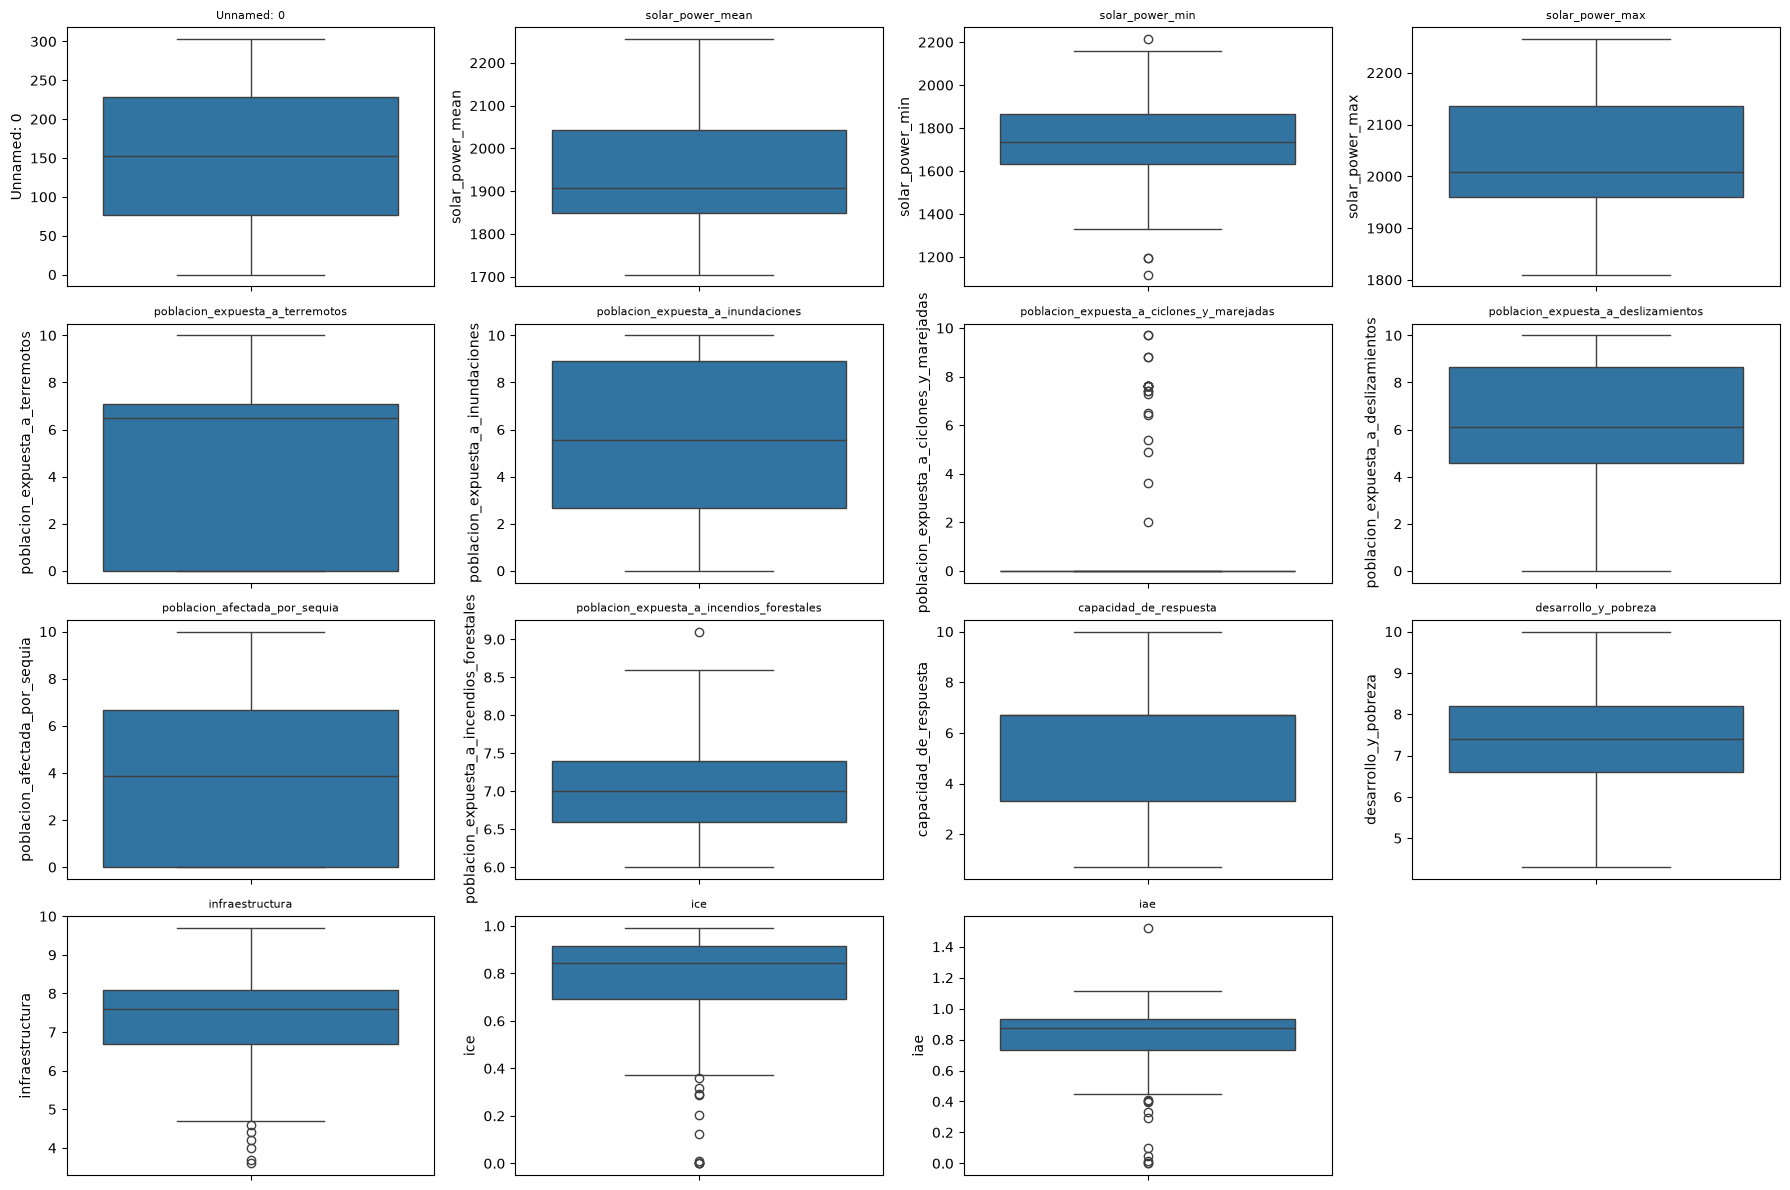

In [57]:
fig, axes = plt.subplots(nrows=int(np.ceil(len(numeric_cols)/4)), ncols=4,
                          figsize=(18, 3*np.ceil(len(numeric_cols)/4)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### Bloque 3 — Matriz de correlación (detectar redundancia)
Si dos variables correlacionan muy fuerte (|r| > 0.8), están midiendo
casi lo mismo. Antes de decidir pesos, revisa esto para no duplicar
el mismo concepto de riesgo dos veces.
 

In [71]:
def plot_correlation(data: pd.DataFrame, cols: list, threshold: float = 0.8):
    """Plot correlation heatmap and list pairs above threshold."""
    corr = data[cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Matriz de correlación")
    plt.tight_layout()
    plt.show()
 
    high_corr_pairs = []
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr.iloc[i, j]
            if abs(r) >= threshold:
                high_corr_pairs.append((cols[i], cols[j], round(r, 2)))
    return pd.DataFrame(high_corr_pairs, columns=["var_1", "var_2", "correlation"])
 

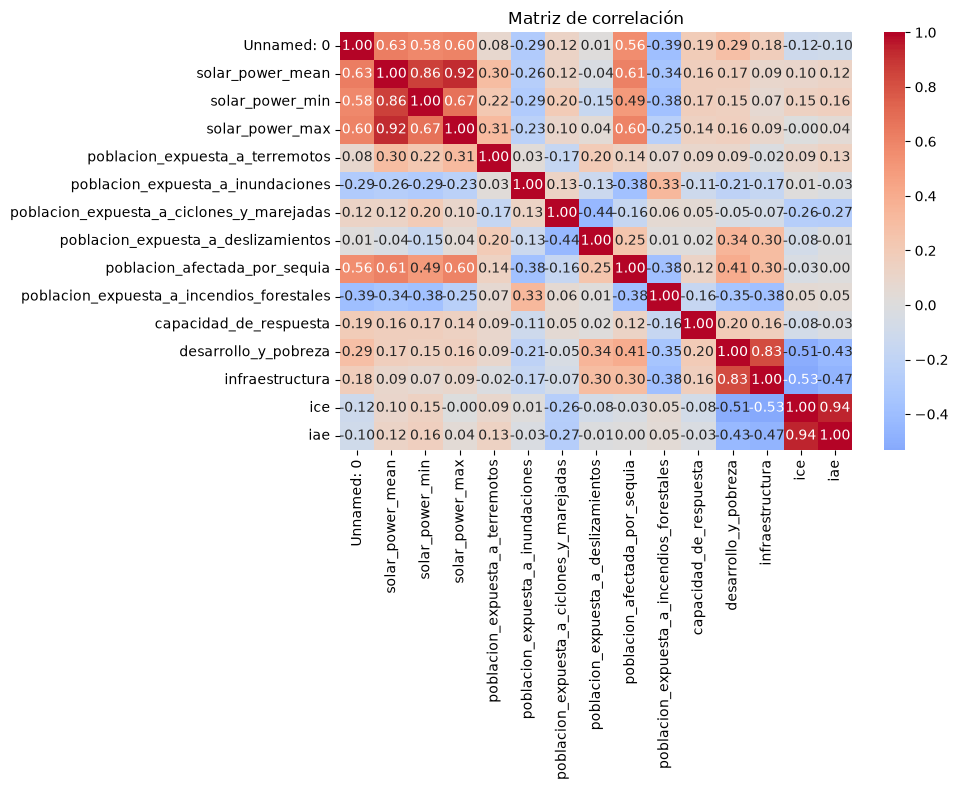

,var_1,var_2,correlation
0,solar_power_mean,solar_power_min,0.86
1,solar_power_mean,solar_power_max,0.92
2,desarrollo_y_pobreza,infraestructura,0.83
3,ice,iae,0.94


In [72]:
high_corr = plot_correlation(df, numeric_cols)
high_corr

### Bloque 4 — Selección final de variables

# Con base en los 3 bloques anteriores, decide manualmente qué se queda.
# Documenta el criterio (esto es lo que defiendes oralmente).

Ejemplo de decisión (AJUSTA según tus propios resultados):
- Se descartan variables con >30% de missing sin justificación de imputación.
- Se descartan variables con CV muy bajo (no discriminan).
- De cada par altamente correlacionado, se conserva solo una.
 

In [60]:
selected_vars = [
    "solar_power_mean",
    "poblacion_expuesta_a_terremotos",
    "poblacion_expuesta_a_inundaciones",
    "poblacion_expuesta_a_ciclones_y_marejadas",
    "poblacion_expuesta_a_deslizamientos",
    "poblacion_afectada_por_sequia",
    "poblacion_expuesta_a_incendios_forestales",
    "capacidad_de_respuesta",
    "infraestructura",
    "iae",
]

id_vars = ["departamento", "municipio", "codigo_departamental", "codigo_municipal"]
df_model = df[id_vars + selected_vars].copy()
df_model.head()
 

,departamento,municipio,codigo_departamental,codigo_municipal,solar_power_mean,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,capacidad_de_respuesta,infraestructura,iae
0,Islas De La Bahia,Guanaja,HN11,HN1102,1988.934501,0.0,0.0,8.8,0.0,0.0,6.6,3.3,4.7,NaN
1,Islas De La Bahia,Jose Santos Guardiola,HN11,HN1103,2012.974138,0.0,1.3,7.6,0.0,0.0,6.8,6.7,5.5,NaN
2,Islas De La Bahia,Roatan,HN11,HN1101,2009.962306,0.0,5.5,7.6,0.0,0.0,8.1,6.7,5.1,NaN
3,Colon,Trujillo,HN02,HN0201,1964.558803,0.0,9.0,0.0,3.1,0.0,7.5,3.3,6.3,0.9642
4,Colon,Iriona,HN02,HN0203,1791.207199,0.0,8.9,8.8,5.0,0.0,7.0,3.3,8.2,0.0963


## Bloque 5 — Tratamiento de datos faltantes

`ice` e `iae` tienen missing en la muestra. Antes de imputar, revisa el
patrón: si faltan en municipios de un mismo departamento, Algunos municipios los podemos descartar por que simplemente tienen 0 y esto pasa con las islas o municipios demasiado isolados.


 


In [61]:
def impute_by_group(data: pd.DataFrame, cols: list, group_col: str = "departamento") -> pd.DataFrame:
    """Impute missing values with the median within each group (department).
    Falls back to the global median if the whole group is missing."""
    data = data.copy()
    for col in cols:
        data[col] = data.groupby(group_col)[col].transform(
            lambda x: x.fillna(x.median())
        )
        # fallback global si el grupo entero estaba vacío
        data[col] = data[col].fillna(data[col].median())
    return data

In [62]:
cols_with_missing = df_model[selected_vars].columns[df_model[selected_vars].isnull().any()].tolist()
print("Columnas con datos faltantes:", cols_with_missing)
 
df_model = df_model.dropna()
 
# Verificación: ya no debe haber nulos
assert df_model[selected_vars].isnull().sum().sum() == 0, "Aún hay valores nulos"
 

Columnas con datos faltantes: ['poblacion_expuesta_a_inundaciones', 'iae']


## Bloque 6 — Normalización (min-max con dirección)

- Regla clave: variables donde "mayor es mejor" (irradiación, ICE, IAE,
- infraestructura, capacidad de respuesta) se normalizan directo.
- Variables donde "mayor es peor" (exposición a riesgos) se normalizan
- invertidas, para que un valor alto de riesgo reste en vez de sumar.

In [63]:
def normalize_min_max(series: pd.Series, invert: bool = False) -> pd.Series:
    """Min-max normalize a series to [0, 1]. If invert=True, higher raw
    values map to lower normalized scores (use for risk/negative indicators)."""
    min_val, max_val = series.min(), series.max()
    if max_val == min_val:
        # sin variación: no discrimina, se asigna 0.5 constante
        return pd.Series(0.5, index=series.index)
    norm = (series - min_val) / (max_val - min_val)
    return 1 - norm if invert else norm


def normalize_dataframe(data: pd.DataFrame, direction_map: dict) -> pd.DataFrame:
    """Apply normalize_min_max to each column according to its direction.
    direction_map: {column_name: 'benefit' or 'cost'}
    'benefit' = higher raw value is better (no invert)
    'cost'    = higher raw value is worse (invert)
    """
    normalized = pd.DataFrame(index=data.index)
    for col, direction in direction_map.items():
        invert = (direction == "cost")
        normalized[col + "_norm"] = normalize_min_max(data[col], invert=invert)
    return normalized
 

In [64]:
direction_map = {
    "solar_power_mean": "benefit",
    "poblacion_expuesta_a_terremotos": "cost",
    "poblacion_expuesta_a_inundaciones": "cost",
    "poblacion_expuesta_a_ciclones_y_marejadas": "cost",
    "poblacion_expuesta_a_deslizamientos": "cost",
    "poblacion_afectada_por_sequia": "cost",
    "poblacion_expuesta_a_incendios_forestales": "cost",
    "capacidad_de_respuesta": "benefit",
    "infraestructura": "benefit",
    #"ice": "benefit",
    "iae": "benefit",
}

df_norm = normalize_dataframe(df_model, direction_map)
df_norm = pd.concat([df_model[id_vars], df_norm], axis=1)
df_norm.head()

,departamento,municipio,codigo_departamental,codigo_municipal,solar_power_mean_norm,poblacion_expuesta_a_terremotos_norm,poblacion_expuesta_a_inundaciones_norm,poblacion_expuesta_a_ciclones_y_marejadas_norm,poblacion_expuesta_a_deslizamientos_norm,poblacion_afectada_por_sequia_norm,poblacion_expuesta_a_incendios_forestales_norm,capacidad_de_respuesta_norm,infraestructura_norm,iae_norm
3,Colon,Trujillo,HN02,HN0201,0.471655,1.00,0.10,1.000000,0.69,1.0,0.516129,0.279570,0.442623,0.866307
4,Colon,Iriona,HN02,HN0203,0.156667,1.00,0.11,0.092784,0.50,1.0,0.677419,0.279570,0.754098,0.086523
5,Colon,Santa Rosa De Aguan,HN02,HN0207,0.546793,1.00,0.12,0.216495,0.73,1.0,0.483871,0.688172,0.672131,0.756334
6,Atlantida,Tela,HN01,HN0107,0.294436,0.09,0.04,1.000000,0.57,1.0,0.516129,0.279570,0.311475,0.667385
7,Colon,Limon,HN02,HN0204,0.362375,1.00,0.13,0.237113,0.63,1.0,0.548387,0.645161,0.803279,0.669721


### Bloque 7 — Ponderación y cálculo del índice compuesto

- Suma ponderada lineal. Los pesos deben sumar 1.0. Ajusta según tu
- justificación (irradiación como factor técnico dominante, riesgo como
- factor de sostenibilidad de la inversión, etc.).

In [65]:
weights = {
    "solar_power_mean_norm": 0.35,
    "poblacion_expuesta_a_terremotos_norm": 0.08,
    "poblacion_expuesta_a_inundaciones_norm": 0.08,
    "poblacion_expuesta_a_ciclones_y_marejadas_norm": 0.06,
    "poblacion_expuesta_a_deslizamientos_norm": 0.06,
    "poblacion_afectada_por_sequia_norm": 0.06,
    "poblacion_expuesta_a_incendios_forestales_norm": 0.06,
    "capacidad_de_respuesta_norm": 0.05,
    "infraestructura_norm": 0.10,
    #"ice_norm": 0.05,
    "iae_norm": 0.10,
}
 
assert abs(sum(weights.values()) - 1.0) < 1e-6, "Los pesos deben sumar 1.0"
 
 
def compute_composite_index(data: pd.DataFrame, weights: dict, index_name: str = "solar_suitability_index") -> pd.DataFrame:
    """Compute weighted linear composite index from normalized columns."""
    data = data.copy()
    data[index_name] = sum(data[col] * w for col, w in weights.items())
    return data
 

In [66]:
df_index = compute_composite_index(df_norm, weights)
df_index = df_index.sort_values("solar_suitability_index", ascending=False)
df_index[id_vars + ["solar_suitability_index"]].head(15)
 

,departamento,municipio,codigo_departamental,codigo_municipal,solar_suitability_index
279,Valle,Alianza,HN17,HN1702,0.746999
259,Francisco Morazan,San Miguelito,HN08,HN0821,0.745637
254,Francisco Morazan,Nueva Armenia,HN08,HN0812,0.743624
268,El Paraiso,Vado Ancho,HN07,HN0717,0.728568
253,Valle,Caridad,HN17,HN1705,0.726450
241,Intibuca,Magdalena,HN10,HN1008,0.719775
242,Intibuca,Santa Lucia,HN10,HN1015,0.716642
227,Lempira,Mapulaca,HN13,HN1314,0.716188
265,Francisco Morazan,La Libertad,HN08,HN0807,0.715545
285,Valle,Amapala,HN17,HN1703,0.708174


### Bloque 8 — Análisis de sensibilidad

- Verifica si el ranking cambia drásticamente al mover los pesos ±10%.
- Si el municipio top-5 se mantiene estable, tu índice es robusto.
 

In [67]:
def sensitivity_test(data: pd.DataFrame, weights: dict, pct_change: float = 0.10, n_runs: int = 20, seed: int = 42) -> pd.DataFrame:
    """Randomly perturb each weight by +/- pct_change, renormalize to sum 1,
    recompute the index, and track how often each municipality lands in the top 5."""
    rng = np.random.default_rng(seed)
    top5_counter = {}
 
    for _ in range(n_runs):
        perturbed = {
            col: max(w * (1 + rng.uniform(-pct_change, pct_change)), 0)
            for col, w in weights.items()
        }
        total = sum(perturbed.values())
        perturbed = {col: w / total for col, w in perturbed.items()}
 
        temp = compute_composite_index(data, perturbed, index_name="_temp_index")
        top5 = temp.nlargest(5, "_temp_index")["municipio"]
        for m in top5:
            top5_counter[m] = top5_counter.get(m, 0) + 1
 
    result = pd.Series(top5_counter, name="times_in_top5").sort_values(ascending=False)
    return (result / n_runs * 100).round(1).rename("pct_runs_in_top5")
 

sensitivity_result = sensitivity_test(df_index, weights)
sensitivity_result
 

Alianza          100.0
San Miguelito    100.0
Nueva Armenia    100.0
Caridad          100.0
Vado Ancho        95.0
Magdalena          5.0
Name: pct_runs_in_top5, dtype: float64

In [68]:
output_cols = id_vars + list(weights.keys()) + ["solar_suitability_index"]
df_index[output_cols].to_csv("indice_idoneidad_solar_resultado.csv", index=False)
print("Archivo exportado: indice_idoneidad_solar_resultado.csv")
 

Archivo exportado: indice_idoneidad_solar_resultado.csv


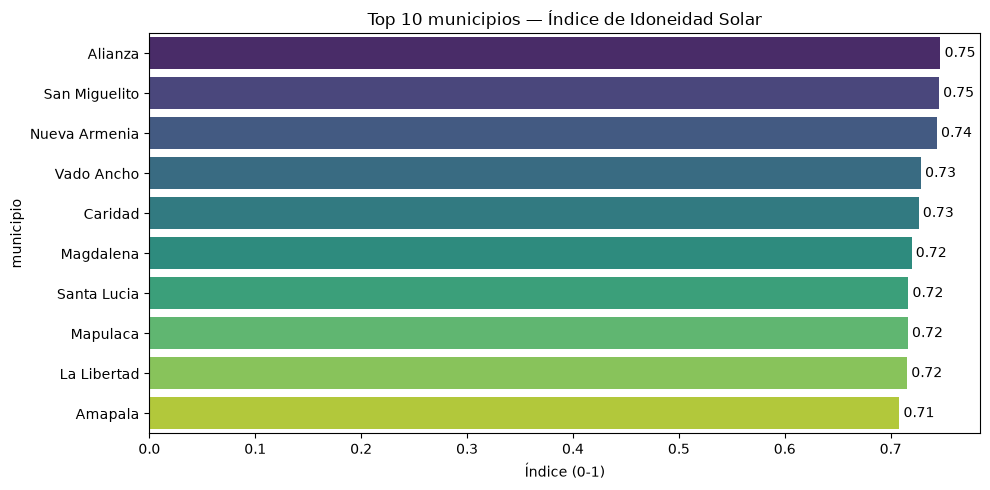

In [69]:
plt.figure(figsize=(10, 5))

# Usamos hue="municipio" y legend=False para evitar la advertencia de Seaborn
ax = sns.barplot(
    data=top10,
    x="solar_suitability_index",
    y="municipio",
    hue="municipio",
    palette="viridis",
    legend=False,
)

# Recorremos todos los contenedores para etiquetar cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Top 10 municipios — Índice de Idoneidad Solar")
plt.xlabel("Índice (0-1)")
plt.tight_layout()
plt.show()

In [70]:
top10.head(10)


,departamento,municipio,codigo_departamental,codigo_municipal,solar_power_mean_norm,poblacion_expuesta_a_terremotos_norm,poblacion_expuesta_a_inundaciones_norm,poblacion_expuesta_a_ciclones_y_marejadas_norm,poblacion_expuesta_a_deslizamientos_norm,poblacion_afectada_por_sequia_norm,poblacion_expuesta_a_incendios_forestales_norm,capacidad_de_respuesta_norm,infraestructura_norm,iae_norm,solar_suitability_index
279,Valle,Alianza,HN17,HN1702,1.000000,0.32,0.07,0.247423,1.00,1.00,0.903226,0.645161,0.573770,0.871249,0.746999
259,Francisco Morazan,San Miguelito,HN08,HN0821,0.825484,0.45,1.00,1.000000,0.48,0.05,0.967742,0.645161,0.737705,0.848248,0.745637
254,Francisco Morazan,Nueva Armenia,HN08,HN0812,0.740710,1.00,1.00,1.000000,0.68,0.48,0.612903,0.645161,0.508197,0.749236,0.743624
268,El Paraiso,Vado Ancho,HN07,HN0717,0.790624,1.00,0.73,1.000000,0.08,0.05,0.903226,1.000000,0.754098,0.660467,0.728568
253,Valle,Caridad,HN17,HN1705,0.790301,0.38,1.00,1.000000,0.37,0.05,0.935484,1.000000,0.688525,0.792633,0.726450
241,Intibuca,Magdalena,HN10,HN1008,0.855956,0.37,1.00,1.000000,0.34,0.07,0.870968,0.645161,0.573770,0.840970,0.719775
242,Intibuca,Santa Lucia,HN10,HN1015,0.867681,0.36,1.00,1.000000,0.07,0.05,0.838710,0.645161,0.704918,0.838814,0.716642
227,Lempira,Mapulaca,HN13,HN1314,0.873440,0.37,1.00,1.000000,0.57,0.06,0.903226,0.279570,0.524590,0.824528,0.716188
265,Francisco Morazan,La Libertad,HN08,HN0807,0.842571,0.41,1.00,1.000000,0.43,0.03,0.870968,0.279570,0.721311,0.818778,0.715545
285,Valle,Amapala,HN17,HN1703,0.984132,0.28,0.44,0.216495,0.69,0.42,0.580645,1.000000,0.540984,0.876011,0.708174
